<a href="https://colab.research.google.com/github/nishasn10/Unsupervised_Learning/blob/main/Association.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Libraries imported successfully!

DATASET INFORMATION

First 5 rows:
              0          1           2                 3             4   \
0         shrimp    almonds     avocado    vegetables mix  green grapes   
1        burgers  meatballs        eggs               NaN           NaN   
2        chutney        NaN         NaN               NaN           NaN   
3         turkey    avocado         NaN               NaN           NaN   
4  mineral water       milk  energy bar  whole wheat rice     green tea   

                 5     6               7             8             9   \
0  whole weat flour  yams  cottage cheese  energy drink  tomato juice   
1               NaN   NaN             NaN           NaN           NaN   
2               NaN   NaN             NaN           NaN           NaN   
3               NaN   NaN             NaN           NaN           NaN   
4               NaN   NaN             NaN           NaN           NaN   

               10         11     12     1

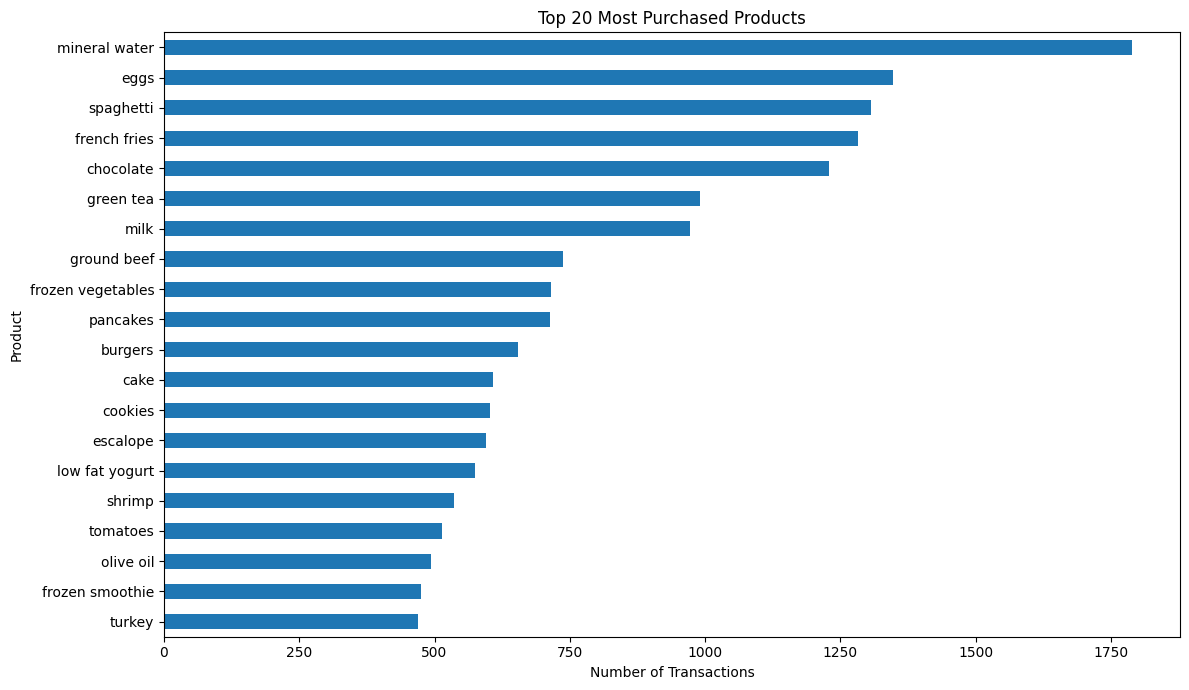


APRIORI ALGORITHM

Number of Frequent Itemsets:
257

Top 20 Apriori Frequent Itemsets:
     support             itemsets  length
46  0.238368      (mineral water)       1
19  0.179709               (eggs)       1
63  0.174110          (spaghetti)       1
24  0.170911       (french fries)       1
13  0.163845          (chocolate)       1
32  0.132116          (green tea)       1
45  0.129583               (milk)       1
33  0.098254        (ground beef)       1
30  0.095321  (frozen vegetables)       1
53  0.095054           (pancakes)       1
6   0.087188            (burgers)       1
8   0.081056               (cake)       1
15  0.080389            (cookies)       1
22  0.079323           (escalope)       1
41  0.076523     (low fat yogurt)       1
61  0.071457             (shrimp)       1
67  0.068391           (tomatoes)       1
52  0.065858          (olive oil)       1
29  0.063325    (frozen smoothie)       1
68  0.062525             (turkey)       1

Number of Apriori Rules:
162


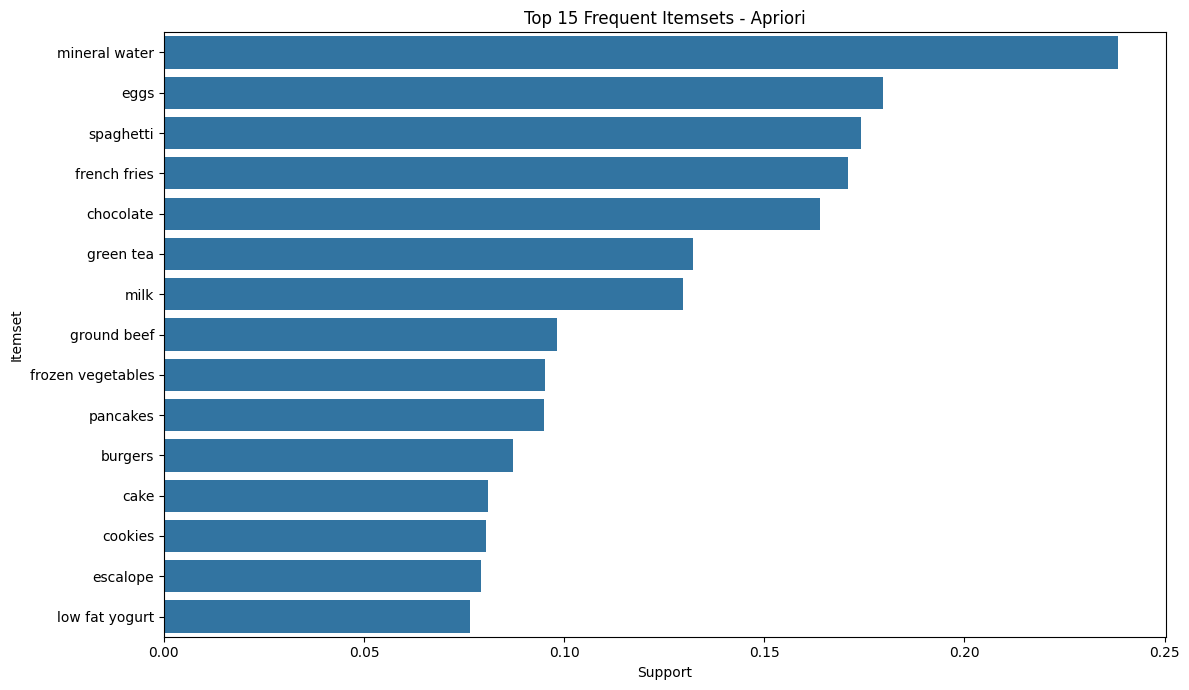

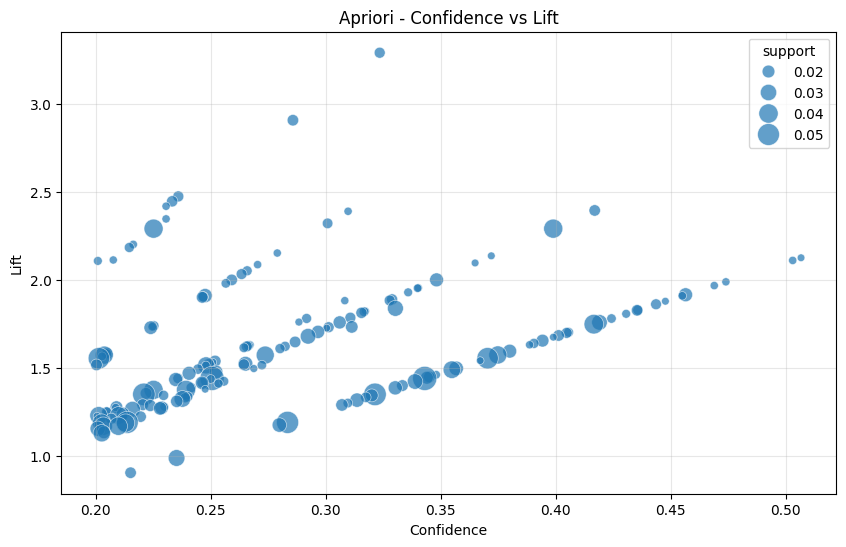

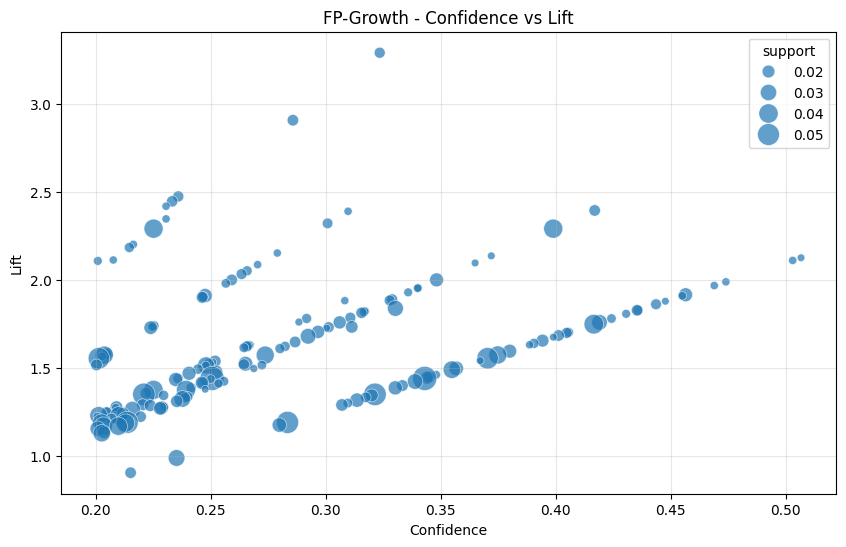

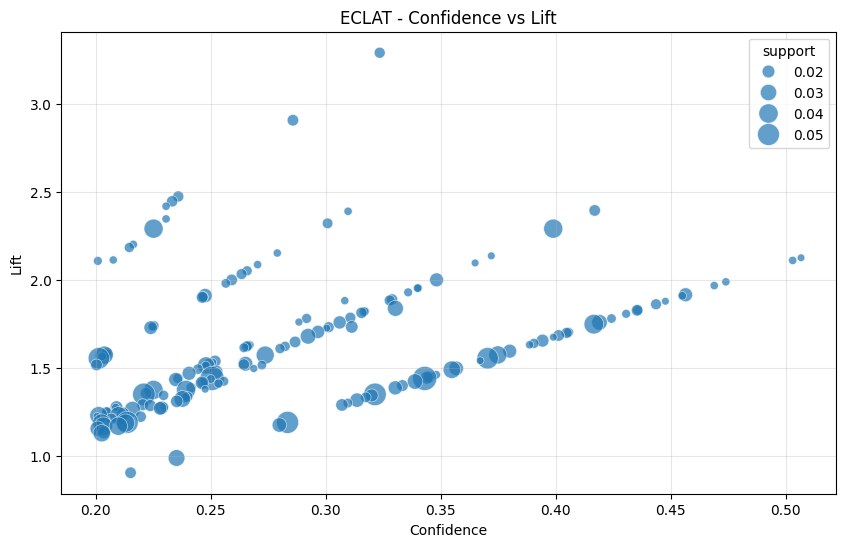

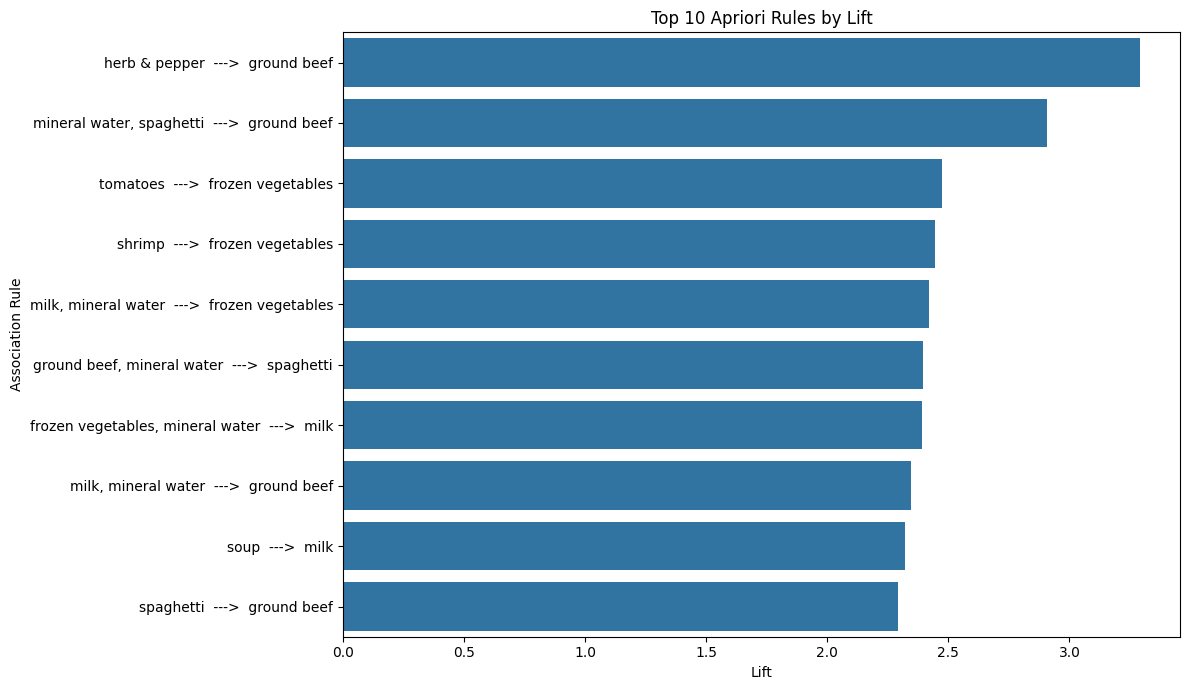


ALGORITHM COMPARISON
   Algorithm  Number_of_Rules
0    Apriori              162
1  FP-Growth              162
2      ECLAT              162


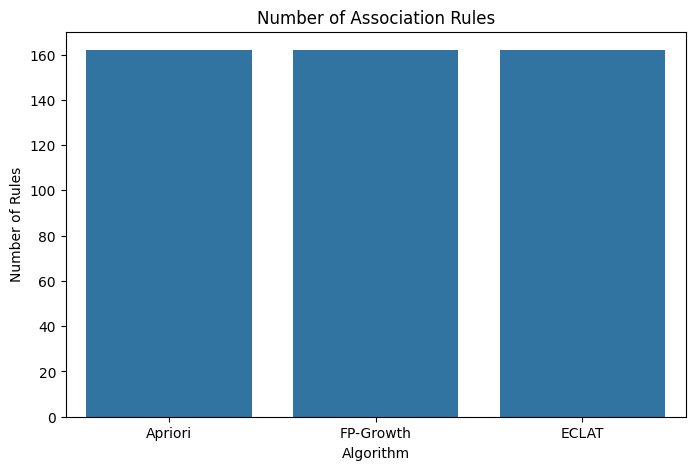


Maximum Lift Comparison:
   Algorithm  Maximum_Lift
0    Apriori      3.291994
1  FP-Growth      3.291994
2      ECLAT      3.291994


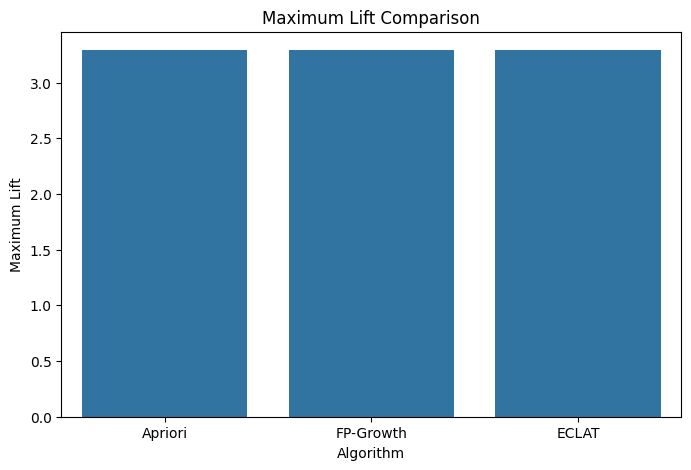



ASSOCIATION RULE LEARNING COMPLETED

Algorithms used:
1. Apriori
2. FP-Growth
3. ECLAT

Evaluation measures:
1. Support
2. Confidence
3. Lift

Files created:
1. apriori_association_rules.csv
2. apriori_frequent_itemsets.csv
3. fpgrowth_association_rules.csv
4. fpgrowth_frequent_itemsets.csv
5. eclat_association_rules.csv
6. eclat_frequent_itemsets.csv

Number of Apriori Rules:
162

Number of FP-Growth Rules:
162

Number of ECLAT Rules:
162

All processing completed successfully!


In [9]:
# ============================================================
# MARKET BASKET OPTIMISATION
# ASSOCIATION RULE LEARNING
#
# Algorithms:
# 1. Apriori
# 2. FP-Growth
# 3. ECLAT
#
# Measures:
# Support
# Confidence
# Lift
#
# Includes:
# - Data preprocessing
# - Frequent itemsets
# - Association rules
# - Graphs
# - Algorithm comparison
# ============================================================


# ============================================================
# 1. HIDE JUPYTER DEPRECATION WARNINGS
# ============================================================

import warnings

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning
)

warnings.filterwarnings(
    "ignore",
    message=".*datetime.utcnow.*"
)


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations

from mlxtend.preprocessing import TransactionEncoder

from mlxtend.frequent_patterns import (
    apriori,
    fpgrowth,
    association_rules
)

print("Libraries imported successfully!")


# ============================================================
# 3. LOAD DATASET
# ============================================================

file_path = "/content/Market_Basket_Optimisation.csv"

df = pd.read_csv(
    file_path,
    header=None
)

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Transactions:")
print(len(df))


# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")

print(
    df.isnull().sum().sum()
)


# ============================================================
# 5. CONVERT DATA INTO TRANSACTIONS
# ============================================================

transactions = []

for i in range(len(df)):

    items = (
        df.iloc[i]
        .dropna()
        .astype(str)
        .tolist()
    )

    items = [
        item.strip()
        for item in items
        if item.strip() != ""
    ]

    transactions.append(items)


print("\nFirst 5 Transactions:")

for transaction in transactions[:5]:

    print(transaction)


# ============================================================
# 6. TRANSACTION STATISTICS
# ============================================================

total_transactions = len(
    transactions
)

unique_products = set()

total_products = 0

for transaction in transactions:

    total_products += len(
        transaction
    )

    unique_products.update(
        transaction
    )


print("\n" + "=" * 60)
print("TRANSACTION STATISTICS")
print("=" * 60)

print(
    "Total Transactions:",
    total_transactions
)

print(
    "Total Products Purchased:",
    total_products
)

print(
    "Unique Products:",
    len(unique_products)
)


# ============================================================
# 7. TRANSACTION ENCODING
# ============================================================

te = TransactionEncoder()

te_array = te.fit(
    transactions
).transform(
    transactions
)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)


print("\nEncoded Dataset:")
print(basket.head())

print("\nEncoded Dataset Shape:")
print(basket.shape)


# ============================================================
# 8. PRODUCT FREQUENCY
# ============================================================

product_frequency = (
    basket.sum()
    .sort_values(
        ascending=False
    )
)


print("\n" + "=" * 60)
print("TOP 20 MOST PURCHASED PRODUCTS")
print("=" * 60)

print(
    product_frequency.head(20)
)


# ============================================================
# 9. GRAPH - TOP PRODUCTS
# ============================================================

plt.figure(
    figsize=(12, 7)
)

product_frequency.head(
    20
).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Most Purchased Products"
)

plt.xlabel(
    "Number of Transactions"
)

plt.ylabel(
    "Product"
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. APRIORI ALGORITHM
# ============================================================

print("\n" + "=" * 60)
print("APRIORI ALGORITHM")
print("=" * 60)


# Minimum support
MIN_SUPPORT = 0.01


frequent_itemsets_apriori = apriori(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True
)


# Add itemset length
frequent_itemsets_apriori[
    "length"
] = frequent_itemsets_apriori[
    "itemsets"
].apply(len)


print(
    "\nNumber of Frequent Itemsets:"
)

print(
    len(frequent_itemsets_apriori)
)


# ============================================================
# 11. APRIORI FREQUENT ITEMSETS
# ============================================================

apriori_sorted = (
    frequent_itemsets_apriori
    .sort_values(
        by="support",
        ascending=False
    )
)


print("\nTop 20 Apriori Frequent Itemsets:")

print(
    apriori_sorted.head(20)
)


# ============================================================
# 12. APRIORI ASSOCIATION RULES
# ============================================================

rules_apriori = association_rules(
    frequent_itemsets_apriori,
    metric="confidence",
    min_threshold=0.20
)


# Sort by lift
rules_apriori = (
    rules_apriori
    .sort_values(
        by="lift",
        ascending=False
    )
)


print(
    "\nNumber of Apriori Rules:"
)

print(
    len(rules_apriori)
)


# ============================================================
# 13. APRIORI TOP RULES
# ============================================================

print("\nTop 20 Apriori Rules:")

print(
    rules_apriori[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)


# ============================================================
# 14. FP-GROWTH
# ============================================================

print("\n" + "=" * 60)
print("FP-GROWTH ALGORITHM")
print("=" * 60)


frequent_itemsets_fp = fpgrowth(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True
)


frequent_itemsets_fp[
    "length"
] = frequent_itemsets_fp[
    "itemsets"
].apply(len)


print(
    "\nNumber of FP-Growth Frequent Itemsets:"
)

print(
    len(frequent_itemsets_fp)
)


# ============================================================
# 15. FP-GROWTH ITEMSETS
# ============================================================

fp_sorted = (
    frequent_itemsets_fp
    .sort_values(
        by="support",
        ascending=False
    )
)


print("\nTop 20 FP-Growth Frequent Itemsets:")

print(
    fp_sorted.head(20)
)


# ============================================================
# 16. FP-GROWTH ASSOCIATION RULES
# ============================================================

rules_fp = association_rules(
    frequent_itemsets_fp,
    metric="confidence",
    min_threshold=0.20
)


rules_fp = (
    rules_fp
    .sort_values(
        by="lift",
        ascending=False
    )
)


print(
    "\nNumber of FP-Growth Rules:"
)

print(
    len(rules_fp)
)


print("\nTop 20 FP-Growth Rules:")

print(
    rules_fp[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)


# ============================================================
# 17. ECLAT ALGORITHM
# ============================================================

print("\n" + "=" * 60)
print("ECLAT ALGORITHM")
print("=" * 60)


# ============================================================
# 18. CREATE VERTICAL DATA
# ============================================================

vertical_data = {}

for transaction_id, transaction in enumerate(
    transactions
):

    for item in transaction:

        if item not in vertical_data:

            vertical_data[item] = set()

        vertical_data[item].add(
            transaction_id
        )


print(
    "\nNumber of unique products for ECLAT:"
)

print(
    len(vertical_data)
)


# ============================================================
# 19. ECLAT FUNCTION
# ============================================================

def eclat(
    prefix,
    items,
    min_support_count,
    results
):

    while items:

        item, tidset = items.pop()

        support_count = len(
            tidset
        )

        if support_count >= min_support_count:

            new_itemset = (
                prefix + [item]
            )

            results.append(
                (
                    tuple(new_itemset),
                    support_count
                )
            )

            suffix = []

            for other_item, other_tidset in items:

                intersection = (
                    tidset &
                    other_tidset
                )

                if (
                    len(intersection)
                    >= min_support_count
                ):

                    suffix.append(
                        (
                            other_item,
                            intersection
                        )
                    )

            eclat(
                new_itemset,
                suffix,
                min_support_count,
                results
            )


# ============================================================
# 20. RUN ECLAT
# ============================================================

eclat_results = []

MIN_SUPPORT_COUNT = int(
    MIN_SUPPORT *
    total_transactions
)


items_for_eclat = [
    (item, tids)
    for item, tids
    in vertical_data.items()
]


eclat(
    [],
    items_for_eclat,
    MIN_SUPPORT_COUNT,
    eclat_results
)


# ============================================================
# 21. ECLAT DATAFRAME
# ============================================================

eclat_df = pd.DataFrame(
    eclat_results,
    columns=[
        "itemsets",
        "support_count"
    ]
)


eclat_df["support"] = (
    eclat_df[
        "support_count"
    ] /
    total_transactions
)


eclat_df["length"] = (
    eclat_df[
        "itemsets"
    ].apply(len)
)


eclat_df = (
    eclat_df
    .sort_values(
        by="support",
        ascending=False
    )
)


print(
    "\nNumber of ECLAT Frequent Itemsets:"
)

print(
    len(eclat_df)
)


# ============================================================
# 22. ECLAT FREQUENT ITEMSETS
# ============================================================

print(
    "\nTop 20 ECLAT Frequent Itemsets:"
)

print(
    eclat_df.head(20)
)


# ============================================================
# 23. CREATE ECLAT SUPPORT DICTIONARY
# ============================================================

support_dict = {}

for _, row in eclat_df.iterrows():

    itemset = frozenset(
        row["itemsets"]
    )

    support_dict[itemset] = (
        row["support"]
    )


# ============================================================
# 24. GENERATE ECLAT ASSOCIATION RULES
# ============================================================

eclat_rules = []


for _, row in eclat_df.iterrows():

    itemset = frozenset(
        row["itemsets"]
    )

    support = row["support"]

    if len(itemset) < 2:
        continue

    items = list(itemset)

    for r in range(
        1,
        len(items)
    ):

        for antecedent_tuple in combinations(
            items,
            r
        ):

            antecedent = frozenset(
                antecedent_tuple
            )

            consequent = (
                itemset -
                antecedent
            )

            if len(consequent) == 0:
                continue

            antecedent_support = (
                support_dict.get(
                    antecedent,
                    0
                )
            )

            consequent_support = (
                support_dict.get(
                    consequent,
                    0
                )
            )

            if antecedent_support == 0:
                continue

            if consequent_support == 0:
                continue

            confidence = (
                support /
                antecedent_support
            )

            lift = (
                confidence /
                consequent_support
            )

            eclat_rules.append({

                "antecedents":
                    antecedent,

                "consequents":
                    consequent,

                "support":
                    support,

                "confidence":
                    confidence,

                "lift":
                    lift
            })


# ============================================================
# 25. ECLAT RULE DATAFRAME
# ============================================================

eclat_rules_df = pd.DataFrame(
    eclat_rules
)


if len(eclat_rules_df) > 0:

    eclat_rules_df = (
        eclat_rules_df
        .drop_duplicates()
    )

    eclat_rules_df = (
        eclat_rules_df[
            eclat_rules_df[
                "confidence"
            ] >= 0.20
        ]
    )

    eclat_rules_df = (
        eclat_rules_df
        .sort_values(
            by="lift",
            ascending=False
        )


    )


print(
    "\nNumber of ECLAT Rules:"
)

print(
    len(eclat_rules_df)
)


# ============================================================
# 26. DISPLAY ECLAT RULES
# ============================================================

print(
    "\nTop 20 ECLAT Rules:"
)

if len(eclat_rules_df) > 0:

    print(
        eclat_rules_df[
            [
                "antecedents",
                "consequents",
                "support",
                "confidence",
                "lift"
            ]
        ].head(20)
    )

else:

    print(
        "No ECLAT rules found."
    )


# ============================================================
# 27. FUNCTION TO FORMAT RULES
# ============================================================

def format_rule(row):

    antecedent = ", ".join(
        sorted(
            list(
                row["antecedents"]
            )
        )
    )

    consequent = ", ".join(
        sorted(
            list(
                row["consequents"]
            )
        )
    )

    return (
        antecedent
        + "  --->  "
        + consequent
    )


# ============================================================
# 28. PRINT BEST APRIORI RULES
# ============================================================

print("\n" + "=" * 60)
print("TOP 10 APRIORI RULES")
print("=" * 60)


for _, row in rules_apriori.head(10).iterrows():

    print(
        "\nRule:",
        format_rule(row)
    )

    print(
        "Support:",
        round(
            row["support"],
            4
        )
    )

    print(
        "Confidence:",
        round(
            row["confidence"],
            4
        )
    )

    print(
        "Lift:",
        round(
            row["lift"],
            4
        )
    )


# ============================================================
# 29. PRINT BEST FP-GROWTH RULES
# ============================================================

print("\n" + "=" * 60)
print("TOP 10 FP-GROWTH RULES")
print("=" * 60)


for _, row in rules_fp.head(10).iterrows():

    print(
        "\nRule:",
        format_rule(row)
    )

    print(
        "Support:",
        round(
            row["support"],
            4
        )
    )

    print(
        "Confidence:",
        round(
            row["confidence"],
            4
        )
    )

    print(
        "Lift:",
        round(
            row["lift"],
            4
        )
    )


# ============================================================
# 30. PRINT BEST ECLAT RULES
# ============================================================

print("\n" + "=" * 60)
print("TOP 10 ECLAT RULES")
print("=" * 60)


if len(eclat_rules_df) > 0:

    for _, row in eclat_rules_df.head(10).iterrows():

        print(
            "\nRule:",
            format_rule(row)
        )

        print(
            "Support:",
            round(
                row["support"],
                4
            )
        )

        print(
            "Confidence:",
            round(
                row["confidence"],
                4
            )
        )

        print(
            "Lift:",
            round(
                row["lift"],
                4
            )
        )


# ============================================================
# 31. GRAPH - APRIORI FREQUENT ITEMSETS
# ============================================================

top_apriori = (
    frequent_itemsets_apriori
    .sort_values(
        by="support",
        ascending=False
    )
    .head(15)
    .copy()
)


top_apriori["itemset_name"] = (
    top_apriori[
        "itemsets"
    ].apply(
        lambda x:
        ", ".join(
            sorted(x)
        )
    )
)


plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=top_apriori,
    y="itemset_name",
    x="support"
)

plt.title(
    "Top 15 Frequent Itemsets - Apriori"
)

plt.xlabel(
    "Support"
)

plt.ylabel(
    "Itemset"
)

plt.tight_layout()

plt.show()


# ============================================================
# 32. GRAPH - APRIORI CONFIDENCE VS LIFT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.scatterplot(
    data=rules_apriori,
    x="confidence",
    y="lift",
    size="support",
    sizes=(30, 300),
    alpha=0.7
)

plt.title(
    "Apriori - Confidence vs Lift"
)

plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Lift"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 33. GRAPH - FP-GROWTH CONFIDENCE VS LIFT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.scatterplot(
    data=rules_fp,
    x="confidence",
    y="lift",
    size="support",
    sizes=(30, 300),
    alpha=0.7
)

plt.title(
    "FP-Growth - Confidence vs Lift"
)

plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Lift"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 34. GRAPH - ECLAT CONFIDENCE VS LIFT
# ============================================================

if len(eclat_rules_df) > 0:

    plt.figure(
        figsize=(10, 6)
    )

    sns.scatterplot(
        data=eclat_rules_df,
        x="confidence",
        y="lift",
        size="support",
        sizes=(30, 300),
        alpha=0.7
    )

    plt.title(
        "ECLAT - Confidence vs Lift"
    )

    plt.xlabel(
        "Confidence"
    )

    plt.ylabel(
        "Lift"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()


# ============================================================
# 35. TOP APRIORI RULES GRAPH
# ============================================================

top_rules = (
    rules_apriori
    .head(10)
    .copy()
)


top_rules["rule"] = (
    top_rules.apply(
        format_rule,
        axis=1
    )
)


plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=top_rules,
    y="rule",
    x="lift"
)

plt.title(
    "Top 10 Apriori Rules by Lift"
)

plt.xlabel(
    "Lift"
)

plt.ylabel(
    "Association Rule"
)

plt.tight_layout()

plt.show()


# ============================================================
# 36. ALGORITHM RULE COUNT COMPARISON
# ============================================================

rule_comparison = pd.DataFrame({

    "Algorithm": [
        "Apriori",
        "FP-Growth",
        "ECLAT"
    ],

    "Number_of_Rules": [
        len(rules_apriori),
        len(rules_fp),
        len(eclat_rules_df)
    ]
})


print("\n" + "=" * 60)
print("ALGORITHM COMPARISON")
print("=" * 60)

print(
    rule_comparison
)


# ============================================================
# 37. GRAPH - RULE COUNT COMPARISON
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=rule_comparison,
    x="Algorithm",
    y="Number_of_Rules"
)

plt.title(
    "Number of Association Rules"
)

plt.xlabel(
    "Algorithm"
)

plt.ylabel(
    "Number of Rules"
)

plt.show()


# ============================================================
# 38. COMPARE BEST LIFT
# ============================================================

best_lift = pd.DataFrame({

    "Algorithm": [
        "Apriori",
        "FP-Growth",
        "ECLAT"
    ],

    "Maximum_Lift": [
        rules_apriori["lift"].max()
        if len(rules_apriori) > 0
        else 0,

        rules_fp["lift"].max()
        if len(rules_fp) > 0
        else 0,

        eclat_rules_df["lift"].max()
        if len(eclat_rules_df) > 0
        else 0
    ]
})


print("\nMaximum Lift Comparison:")

print(
    best_lift
)


# ============================================================
# 39. GRAPH - MAXIMUM LIFT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=best_lift,
    x="Algorithm",
    y="Maximum_Lift"
)

plt.title(
    "Maximum Lift Comparison"
)

plt.xlabel(
    "Algorithm"
)

plt.ylabel(
    "Maximum Lift"
)

plt.show()


# ============================================================
# 40. SAVE APRIORI RESULTS
# ============================================================

rules_apriori.to_csv(
    "apriori_association_rules.csv",
    index=False
)

frequent_itemsets_apriori.to_csv(
    "apriori_frequent_itemsets.csv",
    index=False
)


# ============================================================
# 41. SAVE FP-GROWTH RESULTS
# ============================================================

rules_fp.to_csv(
    "fpgrowth_association_rules.csv",
    index=False
)

frequent_itemsets_fp.to_csv(
    "fpgrowth_frequent_itemsets.csv",
    index=False
)


# ============================================================
# 42. SAVE ECLAT RESULTS
# ============================================================

eclat_rules_df.to_csv(
    "eclat_association_rules.csv",
    index=False
)

eclat_df.to_csv(
    "eclat_frequent_itemsets.csv",
    index=False
)


# ============================================================
# 43. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("ASSOCIATION RULE LEARNING COMPLETED")
print("=" * 60)

print("\nAlgorithms used:")
print("1. Apriori")
print("2. FP-Growth")
print("3. ECLAT")

print("\nEvaluation measures:")
print("1. Support")
print("2. Confidence")
print("3. Lift")

print("\nFiles created:")
print("1. apriori_association_rules.csv")
print("2. apriori_frequent_itemsets.csv")
print("3. fpgrowth_association_rules.csv")
print("4. fpgrowth_frequent_itemsets.csv")
print("5. eclat_association_rules.csv")
print("6. eclat_frequent_itemsets.csv")

print("\nNumber of Apriori Rules:")
print(len(rules_apriori))

print("\nNumber of FP-Growth Rules:")
print(len(rules_fp))

print("\nNumber of ECLAT Rules:")
print(len(eclat_rules_df))

print("\nAll processing completed successfully!")